In [63]:
# DS 4002 Project 2
# Group 7: Zane Abbud, Kaleigh West, Sophie Ogilvie
# File purpose:
# This script analyzes S&P 500 volatility across the Trump (2017–2021),
# Biden (2021–2025), and Trump second term-to-date (2025–present) administrations.
#
# Main tasks performed:
# 1. Import and clean daily S&P 500 data
# 2. Compute daily returns and exploratory rolling volatility
# 3. Label administration periods using inauguration cutoffs
# 4. Define extreme-volatility days using the 90th percentile of absolute returns
# 5. Aggregate daily returns into weekly volatility summaries
# 6. Compare weekly volatility distributions across administrations using Kruskal–Wallis
# 7. Compare extreme-volatility event frequency using a chi-square test
# 8. Estimate odds of an extreme-volatility day by administration using logistic regression

# Notes for anyone running this script:
# - Input file path must point to the cleaned S&P 500 CSV
# - Rolling 5-day and 21-day volatility are used for exploratory analysis only
# - Weekly volatility summaries are used for inferential comparison to reduce temporal dependence
# - Transition weeks containing inauguration dates are removed from weekly comparisons

In [64]:
# Import core libraries for data handling, plotting, and statistical modeling.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

# Import statistical tests
from scipy.stats import kruskal, chi2_contingency
from sklearn.linear_model import LogisticRegression

In [65]:
# Load the cleaned S&P 500 dataset and standardize the date and price column names.
BASE_DIR = Path.cwd()
PATH = BASE_DIR / "sp500_clean.csv"

df = pd.read_csv(PATH)

# Identify possible date and value columns in case naming differs.
date_col_candidates = ["DATE", "date", "observation_date", "Date"]
value_col_candidates = ["SP500", "sp500", "value", "close", "Close"]

date_col = next((c for c in date_col_candidates if c in df.columns), None)
value_col = next((c for c in value_col_candidates if c in df.columns), None)

# Ensure required columns exist before proceeding.
if date_col is None or value_col is None:
    raise ValueError(f"Could not find date/value columns. Found columns: {list(df.columns)}")

# Rename to consistent column names and convert date column.
df = df[[date_col, value_col]].rename(columns={date_col: "date", value_col: "sp500"})
df["date"] = pd.to_datetime(df["date"])

# Sort chronologically and drop rows with missing index values.
df = df.sort_values("date").dropna(subset=["sp500"]).reset_index(drop=True)

# Print basic dataset info for verification.
print("Rows:", len(df))
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

Rows: 2283
Date range: 2017-01-23 to 2026-02-20


In [66]:
# Compute daily log returns and absolute returns to measure volatility.
df["log_return"] = np.log(df["sp500"] / df["sp500"].shift(1))
df["abs_return"] = df["log_return"].abs()

# Create rolling volatility measures (used for exploratory plots, not inference).
df["vol_5d"] = df["log_return"].rolling(window=5).std()
df["vol_21d"] = df["log_return"].rolling(window=21).std()

# Drop rows where returns cannot be computed (first observation).
df = df.dropna(subset=["log_return", "abs_return"]).reset_index(drop=True)

In [67]:
# Define administration cutoff dates.
t1_start = pd.Timestamp("2017-01-20")
biden_start = pd.Timestamp("2021-01-20")
t2_start = pd.Timestamp("2025-01-20")

# Assign each date to a presidential administration period.
def label_admin(d):
    if t1_start <= d < biden_start:
        return "Trump1 (2017–2021)"
    if biden_start <= d < t2_start:
        return "Biden (2021–2025)"
    if d >= t2_start:
        return "Trump2 (2025–present)"
    return "Other"

# Keep only the three administrations of interest.
df["admin_period"] = df["date"].apply(label_admin)
df = df[df["admin_period"].isin(["Trump1 (2017–2021)", "Biden (2021–2025)", "Trump2 (2025–present)"])].copy()
df = df.reset_index(drop=True)

# Define ordering for consistent plotting and summaries.
order = ["Trump1 (2017–2021)", "Biden (2021–2025)", "Trump2 (2025–present)"]
df["admin_period"].value_counts()

admin_period
Biden (2021–2025)        1005
Trump1 (2017–2021)       1004
Trump2 (2025–present)     273
Name: count, dtype: int64

In [68]:
# Define high-volatility days as those above the 90th percentile of absolute returns.
threshold = np.nanpercentile(df["abs_return"], 90)
df["high_vol_event"] = (df["abs_return"] > threshold).astype(int)

# Check threshold and proportion of extreme events.
print("Extreme-event threshold:", threshold)
df["high_vol_event"].value_counts(normalize=True)

Extreme-event threshold: 0.016452399588906538


high_vol_event
0    0.899649
1    0.100351
Name: proportion, dtype: float64

In [69]:
# Convert daily data into weekly periods for independence in statistical testing.
df["week"] = df["date"].dt.to_period("W")

# Compute weekly volatility as the standard deviation of daily returns within each week.
weekly_df = (
    df.groupby(["week", "admin_period"])["log_return"]
    .std()
    .reset_index()
    .rename(columns={"log_return": "weekly_volatility"})
)

# Remove weeks with missing volatility values.
weekly_df = weekly_df.dropna(subset=["weekly_volatility"]).reset_index(drop=True)

# Remove weeks that contain administration transitions to avoid mixing periods.
transition_weeks = [
    pd.Timestamp("2021-01-20").to_period("W"),
    pd.Timestamp("2025-01-20").to_period("W")
]

weekly_df = weekly_df[~weekly_df["week"].isin(transition_weeks)].reset_index(drop=True)

# Verify transition weeks removed and check counts.
weekly_df.head()
weekly_df["week"].isin(transition_weeks).any(), weekly_df.groupby("admin_period").size()

(np.False_,
 admin_period
 Biden (2021–2025)        208
 Trump1 (2017–2021)       208
 Trump2 (2025–present)     56
 dtype: int64)

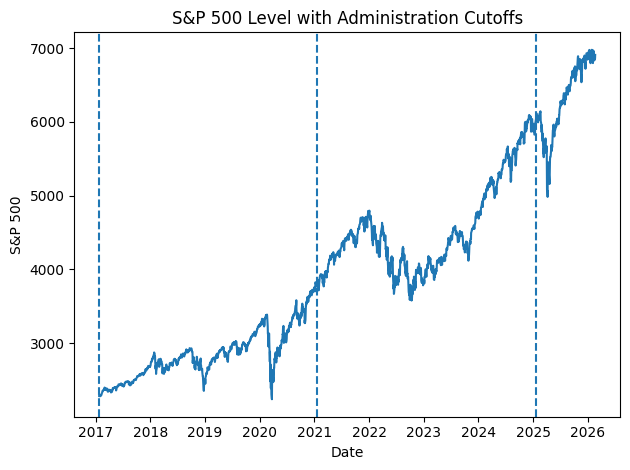

In [70]:
# Plot S&P 500 level with administration cutoffs for context.
plt.figure()
plt.plot(df["date"], df["sp500"])
plt.axvline(t1_start, linestyle="--")
plt.axvline(biden_start, linestyle="--")
plt.axvline(t2_start, linestyle="--")
plt.title("S&P 500 Level with Administration Cutoffs")
plt.xlabel("Date")
plt.ylabel("S&P 500")
plt.tight_layout()
plt.show()

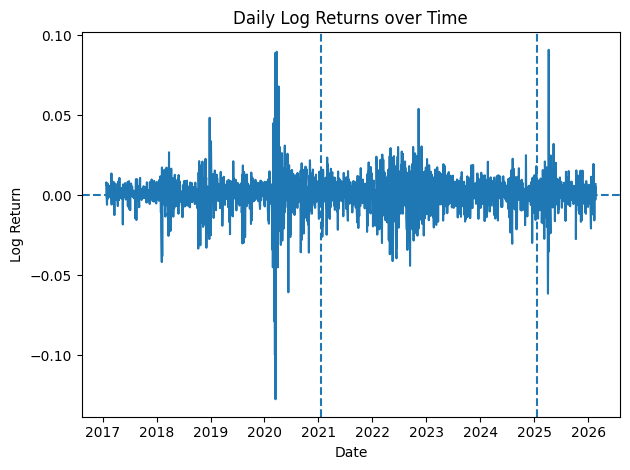

In [71]:
# Plot daily returns to visualize volatility clustering and shocks.
plt.figure()
plt.plot(df["date"], df["log_return"])
plt.axhline(0, linestyle="--")
plt.axvline(biden_start, linestyle="--")
plt.axvline(t2_start, linestyle="--")
plt.title("Daily Log Returns over Time")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.tight_layout()
plt.show()

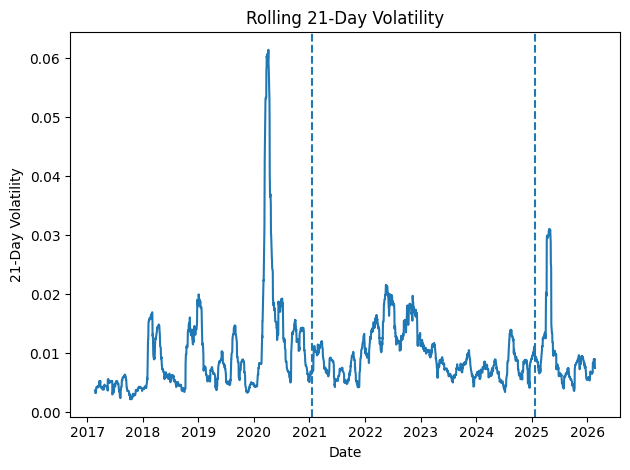

In [72]:
# Plot rolling volatility
df_vol = df.dropna(subset=["vol_21d"]).copy()

plt.figure()
plt.plot(df_vol["date"], df_vol["vol_21d"])
plt.axvline(biden_start, linestyle="--")
plt.axvline(t2_start, linestyle="--")
plt.title("Rolling 21-Day Volatility")
plt.xlabel("Date")
plt.ylabel("21-Day Volatility")
plt.tight_layout()
plt.show()

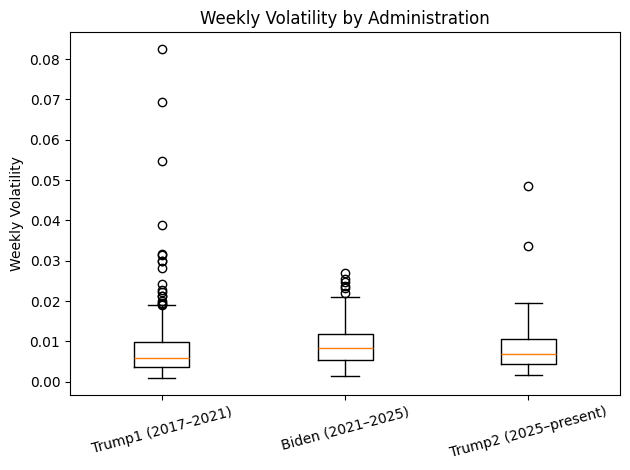

In [73]:
# Visualize distribution of weekly volatility across administrations.
weekly_box = [
    weekly_df.loc[weekly_df["admin_period"] == p, "weekly_volatility"].dropna().values
    for p in order
]

plt.figure()
plt.boxplot(weekly_box, tick_labels=order)
plt.title("Weekly Volatility by Administration")
plt.ylabel("Weekly Volatility")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [74]:
# Create daily summary metrics including volatility and extreme-event rates.
daily_summary = df.groupby("admin_period").agg(
    n_days=("log_return", "size"),
    mean_return=("log_return", "mean"),
    sd_return=("log_return", "std"),
    mean_abs_return=("abs_return", "mean"),
    extreme_event_rate=("high_vol_event", "mean")
).reindex(order)

weekly_summary = weekly_df.groupby("admin_period").agg(
    n_weeks=("weekly_volatility", "size"),
    mean_weekly_volatility=("weekly_volatility", "mean"),
    median_weekly_volatility=("weekly_volatility", "median"),
    iqr_weekly_volatility=("weekly_volatility", lambda x: np.percentile(x, 75) - np.percentile(x, 25)),
    p90_weekly_volatility=("weekly_volatility", lambda x: np.percentile(x, 90))
).reindex(order)

daily_summary

,n_days,mean_return,sd_return,mean_abs_return,extreme_event_rate
admin_period,,,,,
Trump1 (2017–2021),1004,0.000515,0.013021,0.007484,0.099602
Biden (2021–2025),1005,0.000454,0.010414,0.007672,0.105473
Trump2 (2025–present),273,0.000519,0.011383,0.007086,0.084249


In [75]:
# Create weekly summary statistics used for Kruskal–Wallis interpretation.
weekly_summary

,n_weeks,mean_weekly_volatility,median_weekly_volatility,iqr_weekly_volatility,p90_weekly_volatility
admin_period,,,,,
Trump1 (2017–2021),208,0.008755,0.005860,0.006160,0.018137
Biden (2021–2025),208,0.009135,0.008299,0.006414,0.015570
Trump2 (2025–present),56,0.008820,0.006952,0.006043,0.013863


In [76]:
# Test whether weekly volatility distributions differ across administrations.
groups_weekly = [
    weekly_df.loc[weekly_df["admin_period"] == p, "weekly_volatility"].dropna().values
    for p in order
]

kw_weekly = kruskal(*groups_weekly)
print("Kruskal-Wallis result for weekly volatility:")
print(kw_weekly)

Kruskal-Wallis result for weekly volatility:
KruskalResult(statistic=np.float64(16.119738300229756), pvalue=np.float64(0.0003159681469924549))


In [77]:
# Build contingency table of extreme-volatility events by administration.
contingency_table = pd.crosstab(df["admin_period"], df["high_vol_event"]).reindex(order)
contingency_table

high_vol_event,0,1
admin_period,,
Trump1 (2017–2021),904,100
Biden (2021–2025),899,106
Trump2 (2025–present),250,23


In [78]:
# Test whether frequency of extreme-volatility days differs across administrations.
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
expected_df

Chi-square statistic: 1.0822661364937831
p-value: 0.5820883327708699
Degrees of freedom: 2


high_vol_event,0,1
admin_period,,
Trump1 (2017–2021),903.248028,100.751972
Biden (2021–2025),904.147677,100.852323
Trump2 (2025–present),245.604294,27.395706


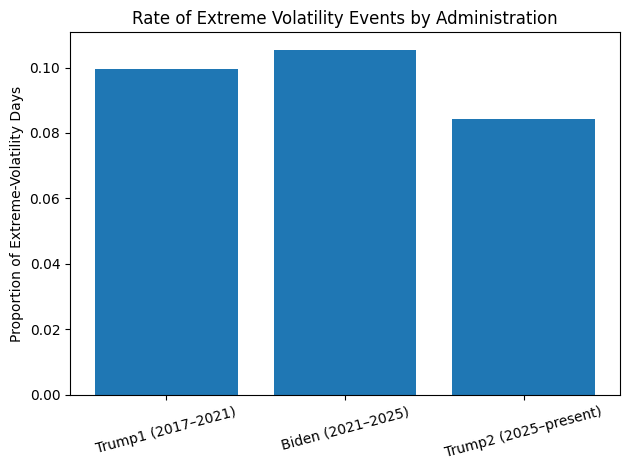

In [79]:
# Plot proportion of extreme-volatility days by administration.
event_rates = df.groupby("admin_period")["high_vol_event"].mean().reindex(order)

plt.figure()
plt.bar(event_rates.index, event_rates.values)
plt.title("Rate of Extreme Volatility Events by Administration")
plt.ylabel("Proportion of Extreme-Volatility Days")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [80]:
# Logistic regression with p-values and confidence intervals
# Estimate odds of an extreme-volatility day by administration (Biden as reference).
# statsmodels is used to obtain p-values and confidence intervals.
import statsmodels.api as sm

X = pd.get_dummies(df["admin_period"], drop_first=False, dtype=int)

if "Biden (2021–2025)" in X.columns:
    X = X.drop(columns=["Biden (2021–2025)"])

X = sm.add_constant(X).astype(float)
y = df["high_vol_event"].astype(int)

logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=False)

conf_int = result.conf_int()

coef_table = pd.DataFrame({
    "Coefficient": result.params,
    "P_Value": result.pvalues,
    "Odds_Ratio": np.exp(result.params),
    "CI_Lower": np.exp(conf_int[0]),
    "CI_Upper": np.exp(conf_int[1])
})

coef_table

,Coefficient,P_Value,Odds_Ratio,CI_Lower,CI_Upper
const,-2.137844,3.013081e-96,0.117909,0.096412,0.144198
Trump1 (2017–2021),-0.063815,6.645202e-01,0.938178,0.703126,1.251809
Trump2 (2025–present),-0.248123,3.029839e-01,0.780264,0.486633,1.251070


In [81]:
# Print key summaries to support interpretation and reporting.
print("Daily summary:")
print(daily_summary)
print("\nWeekly summary:")
print(weekly_summary)
print("\nExtreme-event threshold (90th percentile of absolute returns):", threshold)
print("\nEvent rates:")
print(event_rates)

Daily summary:
                       n_days  mean_return  sd_return  mean_abs_return  \
admin_period                                                             
Trump1 (2017–2021)       1004     0.000515   0.013021         0.007484   
Biden (2021–2025)        1005     0.000454   0.010414         0.007672   
Trump2 (2025–present)     273     0.000519   0.011383         0.007086   

                       extreme_event_rate  
admin_period                               
Trump1 (2017–2021)               0.099602  
Biden (2021–2025)                0.105473  
Trump2 (2025–present)            0.084249  

Weekly summary:
                       n_weeks  mean_weekly_volatility  \
admin_period                                             
Trump1 (2017–2021)         208                0.008755   
Biden (2021–2025)          208                0.009135   
Trump2 (2025–present)       56                0.008820   

                       median_weekly_volatility  iqr_weekly_volatility  \
admin_period